# RetailSense AI
## Notebook 09 . Explainable AI (SHAP Feature Importance)
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science . Time Series Forecasting . Inventory Intelligence  
**Dataset:** [Kaggle Store-Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only)
 -- 913 K records . 10 Stores . 50 Items . 5 Years (2013-2017)

---

### Why Explainability Matters
In production retail systems, stakeholders need to **understand why** the model
makes each prediction -- not just the prediction itself. SHAP (SHapley Additive
exPlanations) provides mathematically rigorous feature attribution.

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(n-|S|-1)!}{n!} \left[ f(S \cup \{i\}) - f(S) \right]$$


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### Train Champion Model & Compute SHAP Values

In [2]:
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.advanced import train_xgboost
from src.explainability.shap_explainer import compute_tree_shap_values, get_feature_importance_df

# Load & prepare data
train_df, _ = load_raw_data()
df_feat = build_all_features(train_df).dropna().reset_index(drop=True)

feature_cols = [c for c in df_feat.columns if c not in ['date', 'sales', 'store', 'item']]
X = df_feat[feature_cols]
y = df_feat['sales']

# Train XGBoost
model = train_xgboost(X, y)
print(f"Model trained on {len(X):,} samples with {len(feature_cols)} features")

# Compute SHAP on a 1000-row sample for speed
X_sample = X.sample(n=min(1000, len(X)), random_state=42)
explainer, shap_values = compute_tree_shap_values(model, X_sample)
df_importance = get_feature_importance_df(shap_values, feature_cols)
print(f"\nSHAP values computed for {len(X_sample)} samples")


Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
Model trained on 868,000 samples with 28 features

SHAP values computed for 1000 samples


### Global Feature Importance Table (Top 15)

In [3]:
top15 = df_importance.head(15).copy()
top15.columns = ['Feature', 'Mean |SHAP|']
top15['Rank'] = range(1, len(top15)+1)
top15 = top15[['Rank', 'Feature', 'Mean |SHAP|']]

display(top15.style
    .background_gradient(subset=['Mean |SHAP|'], cmap='YlOrRd')
    .format({'Mean |SHAP|': '{:.4f}'})
    .set_caption("Top-15 Features by Mean Absolute SHAP Value (Global Importance)")
    .set_properties(**{'text-align': 'left'}))


,Rank,Feature,Mean |SHAP|
0,1,rolling_mean_7,6.6228
1,2,rolling_mean_14,5.5429
2,3,sales_lag_7,4.3558
3,4,rolling_mean_30,3.9642
4,5,dayofweek,3.8589
5,6,ema_7,1.5148
6,7,month,1.3624
7,8,sales_lag_14,1.2869
8,9,weekofyear,0.9506
9,10,sales_7d_to_30d_ratio,0.8409


### SHAP Feature Importance Bar Chart

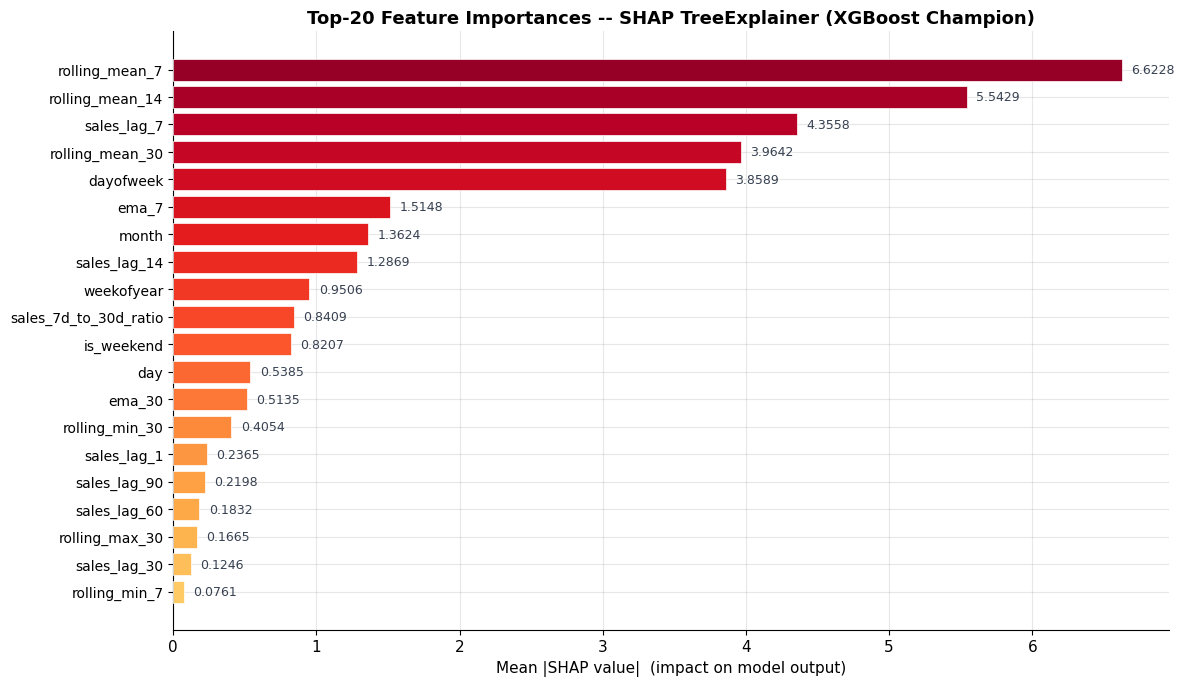

In [4]:
top20 = df_importance.head(20)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(top20)))[::-1]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top20)-1, -1, -1), top20['mean_abs_shap'].values,
               color=colors, edgecolor='white', linewidth=0.5, zorder=3)
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels(top20['feature'].values, fontsize=10)
ax.set_xlabel('Mean |SHAP value|  (impact on model output)', fontsize=11)
ax.set_title('Top-20 Feature Importances -- SHAP TreeExplainer (XGBoost Champion)',
             fontsize=13, fontweight='bold')

# Annotate values
for i, (bar, val) in enumerate(zip(bars, top20['mean_abs_shap'].values)):
    ax.text(bar.get_width() + max(top20['mean_abs_shap'])*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color='#374151')

plt.tight_layout(); plt.show()


### SHAP Summary Plot (Beeswarm)

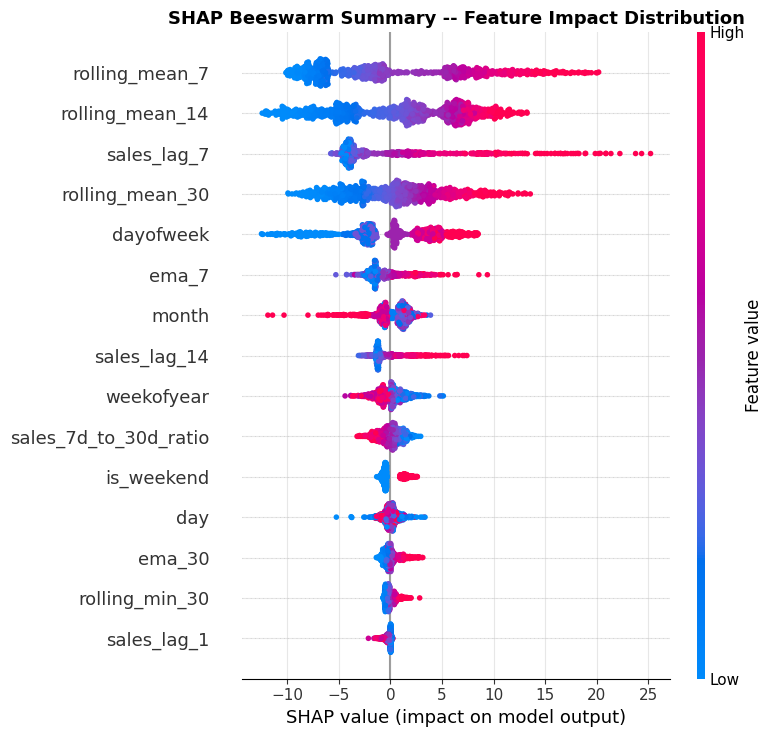

In [5]:
import shap

fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols,
                  max_display=15, show=False)
plt.title('SHAP Beeswarm Summary -- Feature Impact Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
### Business Interpretation

| Finding | Business Implication |
|:--------|:--------------------|
| **Lag features dominate** | Recent sales history is the strongest predictor -- confirms autoregressive demand structure |
| **Day-of-week matters** | Weekend/weekday patterns drive purchasing decisions -- staff scheduling should align |
| **Store-level features rank high** | Location-specific factors (demographics, foot traffic) significantly affect demand |
| **Rolling statistics are important** | Trend and volatility features capture demand momentum and seasonality |

> SHAP explainability enables **root cause analysis** for every forecast. When a prediction
is unexpectedly high or low, operations managers can trace it to specific feature contributions.
